In [3]:
import numpy as np
import pandas as pd
from sksurv.ensemble import RandomSurvivalForest 
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import KFold, StratifiedKFold
from sksurv.metrics import concordance_index_censored
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sksurv.linear_model import CoxPHSurvivalAnalysis


In [4]:
df_radiomics = pd.read_csv('csv/radiomicas_combinadas_normalizado.csv')
df_radiomics["Patient"] = df_radiomics["Patient"].str.replace('"','',regex=False)
df_radiomics.head(5)

,Patient,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_Mean,original_firstorder_MeanAbsoluteDeviation,...,wavelet-LLL_glszm_SmallAreaHighGrayLevelEmphasis,wavelet-LLL_glszm_SmallAreaLowGrayLevelEmphasis,wavelet-LLL_glszm_ZoneEntropy,wavelet-LLL_glszm_ZonePercentage,wavelet-LLL_glszm_ZoneVariance,wavelet-LLL_ngtdm_Busyness,wavelet-LLL_ngtdm_Coarseness,wavelet-LLL_ngtdm_Complexity,wavelet-LLL_ngtdm_Contrast,wavelet-LLL_ngtdm_Strength
0,LUNG1-001,0.264279,-0.471885,-0.279790,0.025573,-0.868932,-0.822722,-0.349502,0.348139,-0.353586,...,0.304767,-0.990892,0.351123,-0.272728,-0.981889,-0.517778,-0.993394,-0.385509,-0.927018,-0.961000
1,LUNG1-002,0.891578,-0.296446,-0.959418,-0.441895,-0.934466,-0.033895,-0.899003,0.711427,-0.869634,...,-0.186468,-0.967982,-0.024807,-0.681319,-0.991054,-0.731196,-0.971461,-0.908586,-0.990167,-0.882556
2,LUNG1-003,0.856728,-0.269456,-0.951453,-0.232302,-0.902913,-0.333322,-0.426578,0.693127,-0.817416,...,0.264072,-0.979473,0.067602,-0.494151,-0.996761,-0.867627,-0.972117,-0.684509,-0.993100,-0.769095
3,LUNG1-004,0.614714,-0.386415,-0.869261,-0.007804,-0.893204,-0.698773,-0.818605,0.464850,-0.517251,...,0.334035,-0.936120,0.444024,-0.353243,-0.998532,-0.911518,-0.953263,-0.681503,-0.939924,-0.699169
4,LUNG1-005,-0.165537,-0.368421,-0.509448,0.272623,-0.771845,-0.875361,-0.887043,0.234176,-0.056650,...,0.340667,-0.946682,0.520499,-0.048338,-0.999756,-0.810449,-0.974874,-0.515473,-0.778467,-0.875750


In [5]:
df_clinic = pd.read_csv('csv/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv')
df_clinic.head(5)

,PatientID,age,clinical.T.Stage,Clinical.N.Stage,Clinical.M.Stage,Overall.Stage,Histology,gender,Survival.time,deadstatus.event
0,LUNG1-001,78.7515,2.0,3,0,IIIb,large cell,male,2165,1
1,LUNG1-002,83.8001,2.0,0,0,I,squamous cell carcinoma,male,155,1
2,LUNG1-003,68.1807,2.0,3,0,IIIb,large cell,male,256,1
3,LUNG1-004,70.8802,2.0,1,0,II,squamous cell carcinoma,male,141,1
4,LUNG1-005,80.4819,4.0,2,0,IIIb,squamous cell carcinoma,male,353,1


In [6]:
df_clinic = df_clinic.dropna(subset=["Overall.Stage"])  # Drop rows with NaN in Overall.Stage column

df_clinic = df_clinic[df_clinic["PatientID"].isin(df_radiomics["Patient"])]  # Keep only patients in df
df_radiomics = df_radiomics[df_radiomics["Patient"].isin(df_clinic["PatientID"])]  # Keep only patients in df_clinic
print(df_radiomics.shape)
print(df_clinic.shape)

(417, 852)
(417, 10)


### RANDOM SURVIVAL FOREST -  TOP RADIOMICS

In [7]:
features = ["wavelet-LLH_ngtdm_Coarseness","original_gldm_DependenceNonUniformity", "wavelet-HHL_ngtdm_Coarseness", "wavelet-HHL_glrlm_RunLengthNonUniformity"]

In [8]:
import joblib


X = df_radiomics[features].values
event = df_clinic['deadstatus.event'].values.astype(bool)
time = df_clinic['Survival.time'].values

# Create structured array for survival data
y = np.array([(e, t) for e, t in zip(event, time)], 
             dtype=[('event', '?'), ('time', '<f8')])



kfold = KFold(n_splits=5, shuffle=True, random_state=42)

train_index,test_index = next(kfold.split(X))
X_train_set, X_test_set = X[train_index], X[test_index]
y_train_set, y_test_set = y[train_index], y[test_index]

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

c_indices = []
best_classifier = None
best_c_index = -1
best_fold = -1

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, test_idx) in enumerate(kfold.split(X_train_set)):
    # FIX: Slice both train and test from the '_set' variables
    X_train, X_test = X_train_set[train_idx], X_train_set[test_idx]
    y_train, y_test = y_train_set[train_idx], y_train_set[test_idx]
    
    classifier = RandomSurvivalForest(n_estimators=100, random_state=42)
    classifier.fit(X_train, y_train)
    
    survival_scores = classifier.predict(X_test)
    
    c_index = concordance_index_censored(
        y_test['event'],
        y_test['time'],
        survival_scores
    )[0]
    c_indices.append(c_index)
    
    # Save best classifier
    if c_index > best_c_index:
        best_c_index = c_index
        best_classifier = classifier
        best_fold = fold

print(f"Concordance Index Scores: {[f'{c:.4f}' for c in c_indices]}")
print(f"Mean Concordance Index: {np.mean(c_indices):.4f} (+/- {np.std(c_indices):.4f})")
print(f"\nBest Classifier - Fold {best_fold}: Concordance Index = {best_c_index:.4f}")
print("Cross-validation complete!")
joblib.dump(best_classifier, 'models/rsf_top_radiomics.pkl')

Concordance Index Scores: ['0.5401', '0.5553', '0.5820', '0.5245', '0.5058']
Mean Concordance Index: 0.5416 (+/- 0.0261)

Best Classifier - Fold 2: Concordance Index = 0.5820
Cross-validation complete!


FileNotFoundError: [Errno 2] No such file or directory: 'models/rsf_top_radiomics.pkl'

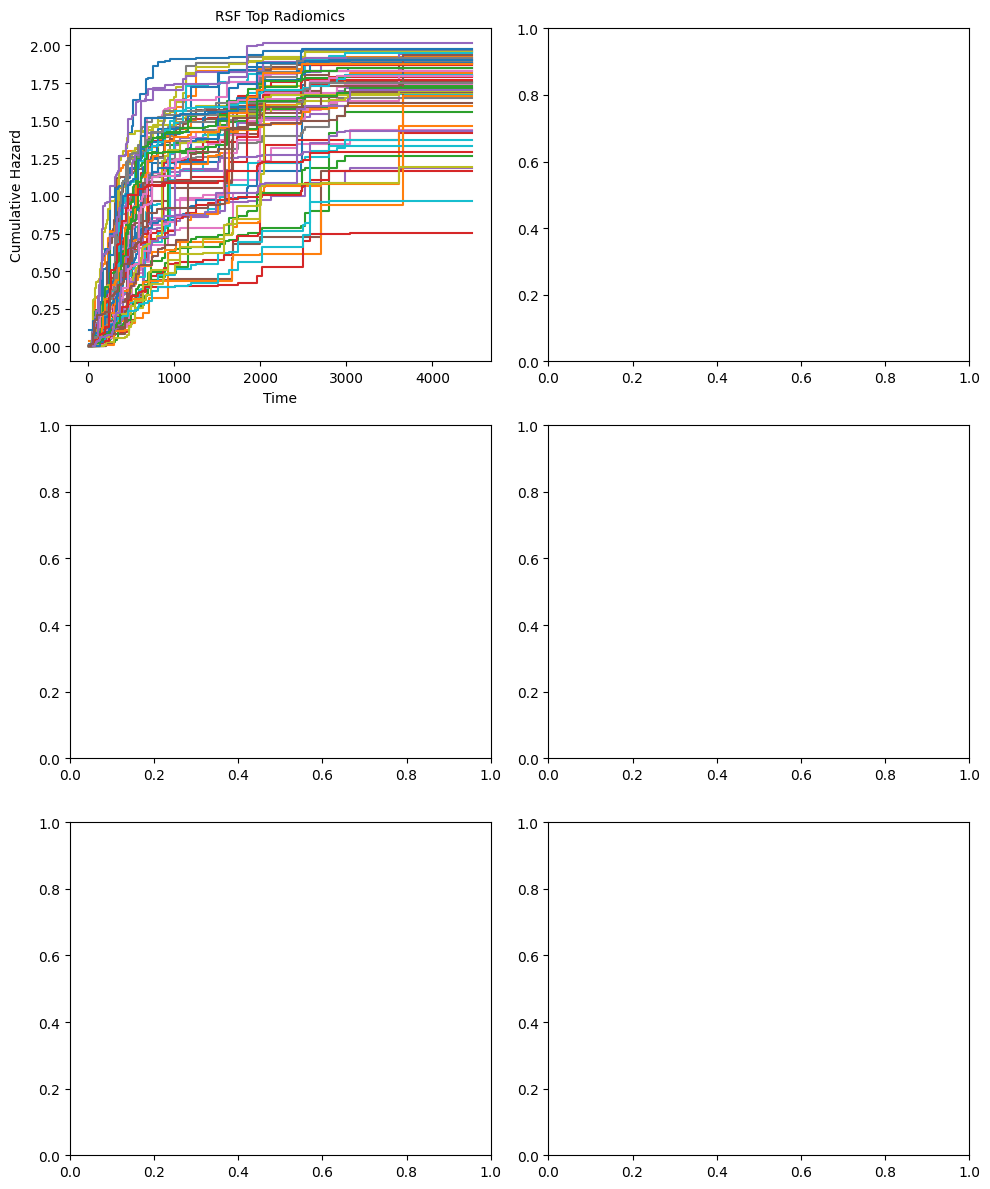

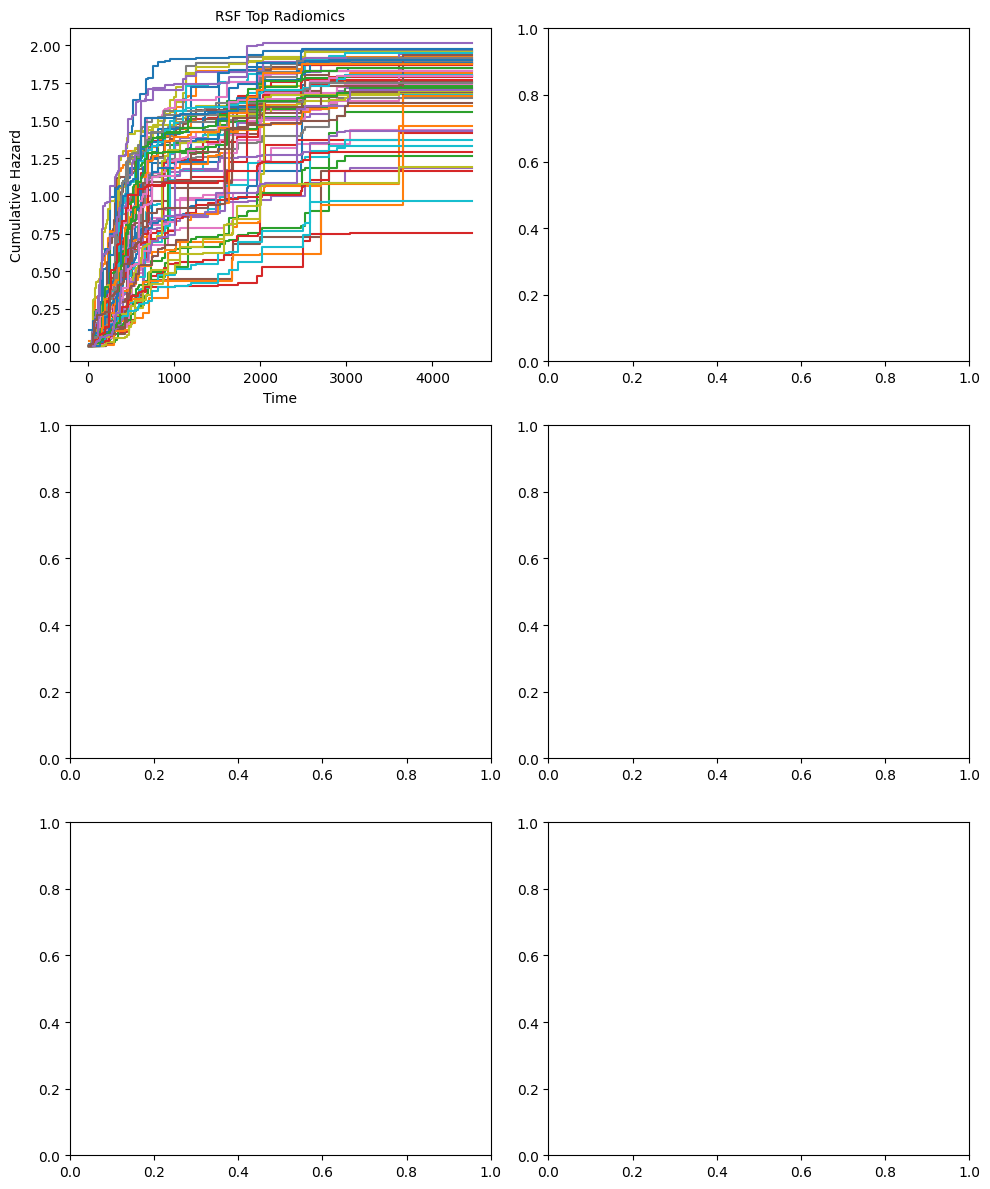

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=3, ncols=2,figsize=(10, 12)) 
axes_flat = axes.flatten()
ax = axes_flat[0]

chf_functions = best_classifier.predict_cumulative_hazard_function(X_test)
for fn in chf_functions:
    ax.step(fn.x, fn(fn.x), where="post")

ax.set_title("RSF Top Radiomics", fontsize=10)
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative Hazard")
plt.tight_layout()
fig



### RANDOM SURVIVAL FOREST - CLINICAL FEATURES 

In [ ]:
features = df_clinic.columns[1:8]

In [ ]:
X = df_clinic[features]
event = df_clinic['deadstatus.event'].values.astype(bool)
time = df_clinic['Survival.time'].values

# Create structured array for survival data
y = np.array([(e, t) for e, t in zip(event, time)], 
             dtype=[('event', '?'), ('time', '<f8')])

categorical_features = ['Overall.Stage', 'Histology', 'gender']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)
X_encoded = preprocessor.fit_transform(X)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

train_index,test_index = next(kfold.split(X_encoded))
X_train_set, X_test_set = X_encoded[train_index], X_encoded[test_index]
y_train_set, y_test_set = y[train_index], y[test_index]

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

c_indices = []
best_classifier = None
best_c_index = -1
best_fold = -1

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, test_idx) in enumerate(kfold.split(X_train_set)):
    # FIX: Slice both train and test from the '_set' variables
    X_train, X_test = X_train_set[train_idx], X_train_set[test_idx]
    y_train, y_test = y_train_set[train_idx], y_train_set[test_idx]
    
    classifier = RandomSurvivalForest(n_estimators=100, random_state=42)
    classifier.fit(X_train, y_train)
    
    survival_scores = classifier.predict(X_test)
    
    c_index = concordance_index_censored(
        y_test['event'],
        y_test['time'],
        survival_scores
    )[0]
    c_indices.append(c_index)
    
    # Save best classifier
    if c_index > best_c_index:
        best_c_index = c_index
        best_classifier = classifier
        best_fold = fold

print(f"Concordance Index Scores: {[f'{c:.4f}' for c in c_indices]}")
print(f"Mean Concordance Index: {np.mean(c_indices):.4f} (+/- {np.std(c_indices):.4f})")
print(f"\nBest Classifier - Fold {best_fold}: Concordance Index = {best_c_index:.4f}")
print("Cross-validation complete!")
joblib.dump(best_classifier, 'models/rsf_clinics.pkl')

Concordance Index Scores: ['0.5712', '0.5272', '0.4869', '0.5575', '0.4774']
Mean Concordance Index: 0.5241 (+/- 0.0372)

Best Classifier - Fold 0: Concordance Index = 0.5712
Cross-validation complete!


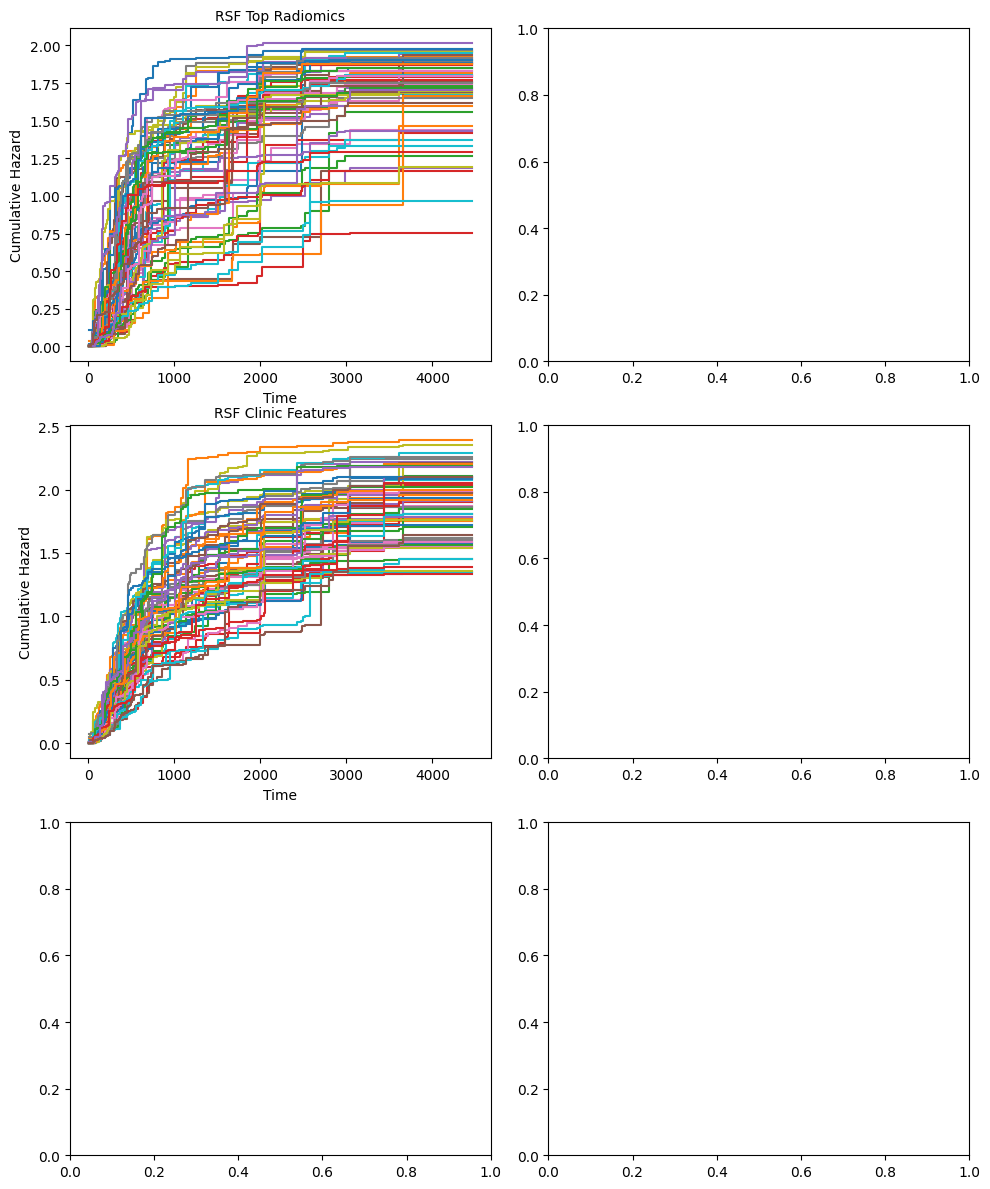

In [ ]:

ax = axes_flat[2]

chf_functions = best_classifier.predict_cumulative_hazard_function(X_test)
for fn in chf_functions:
    ax.step(fn.x, fn(fn.x), where="post")

ax.set_title("RSF Clinic Features", fontsize=10)
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative Hazard")
fig

### RANDOM SURVIVAL FOREST - MIXED FEATURES

In [ ]:
features_clinic = df_clinic.columns[1:8]
features_radiomics = ["wavelet-LLH_ngtdm_Coarseness","original_gldm_DependenceNonUniformity", "wavelet-HHL_ngtdm_Coarseness", "wavelet-HHL_glrlm_RunLengthNonUniformity"]

In [ ]:
# Reset indices to ensure they align by position, not old row labels
X_clinic = df_clinic[features_clinic].reset_index(drop=True)
X_radiomics = df_radiomics[features_radiomics].reset_index(drop=True)

# Concatenate safely
X = pd.concat([X_clinic, X_radiomics], axis=1)

event = df_clinic['deadstatus.event'].values.astype(bool)
time = df_clinic['Survival.time'].values

# Create structured array for survival data
y = np.array([(e, t) for e, t in zip(event, time)], 
             dtype=[('event', '?'), ('time', '<f8')])

categorical_features = ['Overall.Stage', 'Histology', 'gender']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)
X_encoded = preprocessor.fit_transform(X)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

train_index,test_index = next(kfold.split(X_encoded))
X_train_set, X_test_set = X_encoded[train_index], X_encoded[test_index]
y_train_set, y_test_set = y[train_index], y[test_index]

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

c_indices = []
best_classifier = None
best_c_index = -1
best_fold = -1

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, test_idx) in enumerate(kfold.split(X_train_set)):
    # FIX: Slice both train and test from the '_set' variables
    X_train, X_test = X_train_set[train_idx], X_train_set[test_idx]
    y_train, y_test = y_train_set[train_idx], y_train_set[test_idx]
    
    classifier = RandomSurvivalForest(n_estimators=100, random_state=42)
    classifier.fit(X_train, y_train)
    
    survival_scores = classifier.predict(X_test)
    
    c_index = concordance_index_censored(
        y_test['event'],
        y_test['time'],
        survival_scores
    )[0]
    c_indices.append(c_index)
    
    # Save best classifier
    if c_index > best_c_index:
        best_c_index = c_index
        best_classifier = classifier
        best_fold = fold

print(f"Concordance Index Scores: {[f'{c:.4f}' for c in c_indices]}")
print(f"Mean Concordance Index: {np.mean(c_indices):.4f} (+/- {np.std(c_indices):.4f})")
print(f"\nBest Classifier - Fold {best_fold}: Concordance Index = {best_c_index:.4f}")
print("Cross-validation complete!")
joblib.dump(best_classifier, 'models/rsf_mixed.pkl')

Concordance Index Scores: ['0.5791', '0.5393', '0.5048', '0.5617', '0.5029']
Mean Concordance Index: 0.5376 (+/- 0.0303)

Best Classifier - Fold 0: Concordance Index = 0.5791
Cross-validation complete!


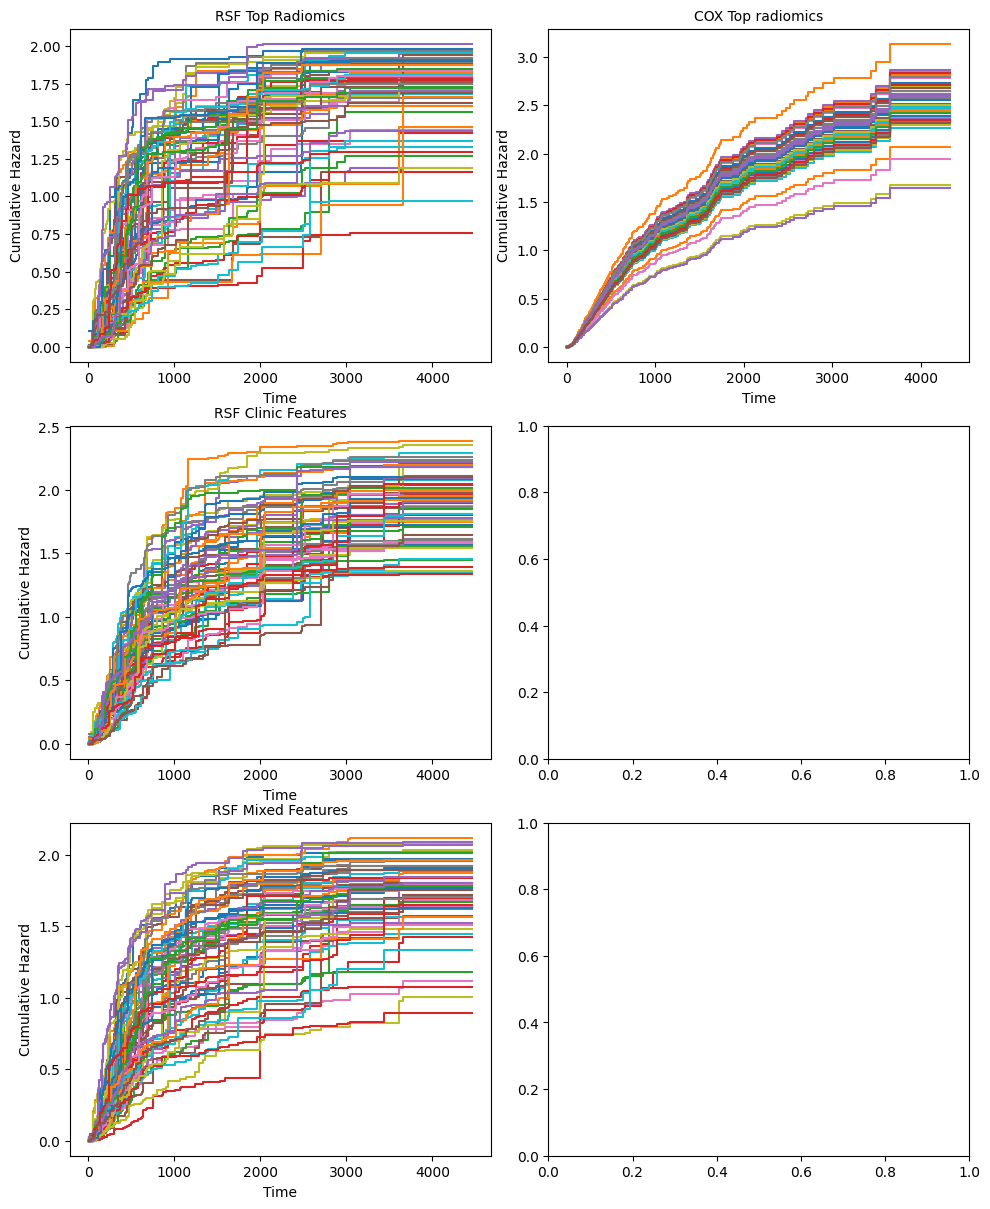

In [ ]:
ax = axes_flat[4]

chf_functions = best_classifier.predict_cumulative_hazard_function(X_test)
for fn in chf_functions:
    ax.step(fn.x, fn(fn.x), where="post")

ax.set_title("RSF Mixed Features", fontsize=10)
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative Hazard")
fig

### COX Proportional Hazards Model - Top radiomics

In [ ]:
features_radiomics = ["wavelet-LLH_ngtdm_Coarseness","original_gldm_DependenceNonUniformity", "wavelet-HHL_ngtdm_Coarseness", "wavelet-HHL_glrlm_RunLengthNonUniformity"]

In [ ]:

X = df_radiomics[features_radiomics].reset_index(drop=True)

event = df_clinic['deadstatus.event'].values.astype(bool)
time = df_clinic['Survival.time'].values

y = np.array([(e, t) for e, t in zip(event, time)], 
             dtype=[('event', '?'), ('time', '<f8')])

categorical_features = []
numerical_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, drop='first'), categorical_features), # drop='first' avoids multicollinearity in Cox
        ('num', StandardScaler(), numerical_features)
    ],
    remainder='passthrough'
)

X_encoded = preprocessor.fit_transform(X)


outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_index, test_index = next(outer_cv.split(X_encoded, event))
X_train_set, X_test_set = X_encoded[train_index], X_encoded[test_index]
y_train_set, y_test_set = y[train_index], y[test_index]
event_train_set = event[train_index] 


inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

c_indices = []
best_classifier = None
best_c_index = -1
best_fold = -1

for fold, (train_idx, test_idx) in enumerate(inner_cv.split(X_train_set, event_train_set)):
    X_train, X_test = X_train_set[train_idx], X_train_set[test_idx]
    y_train, y_test = y_train_set[train_idx], y_train_set[test_idx]
    
    classifier = CoxPHSurvivalAnalysis(alpha=1e-4) 
    classifier.fit(X_train, y_train)
    
    risk_scores = classifier.predict(X_test)
    
    c_index = concordance_index_censored(
        y_test['event'],
        y_test['time'],
        risk_scores
    )[0]
    c_indices.append(c_index)
    
    if c_index > best_c_index:
        best_c_index = c_index
        best_classifier = classifier
        best_fold = fold

print(f"Concordance Index Scores: {[f'{c:.4f}' for c in c_indices]}")
print(f"Mean Concordance Index: {np.mean(c_indices):.4f} (+/- {np.std(c_indices):.4f})")
print(f"\nBest Classifier - Fold {best_fold}: Concordance Index = {best_c_index:.4f}")
print("Cross-validation complete!")
joblib.dump(best_classifier, 'models/cox_top_radiomics.pkl')



Concordance Index Scores: ['0.5434', '0.5551', '0.5042', '0.5224', '0.5748']
Mean Concordance Index: 0.5400 (+/- 0.0247)

Best Classifier - Fold 4: Concordance Index = 0.5748
Cross-validation complete!


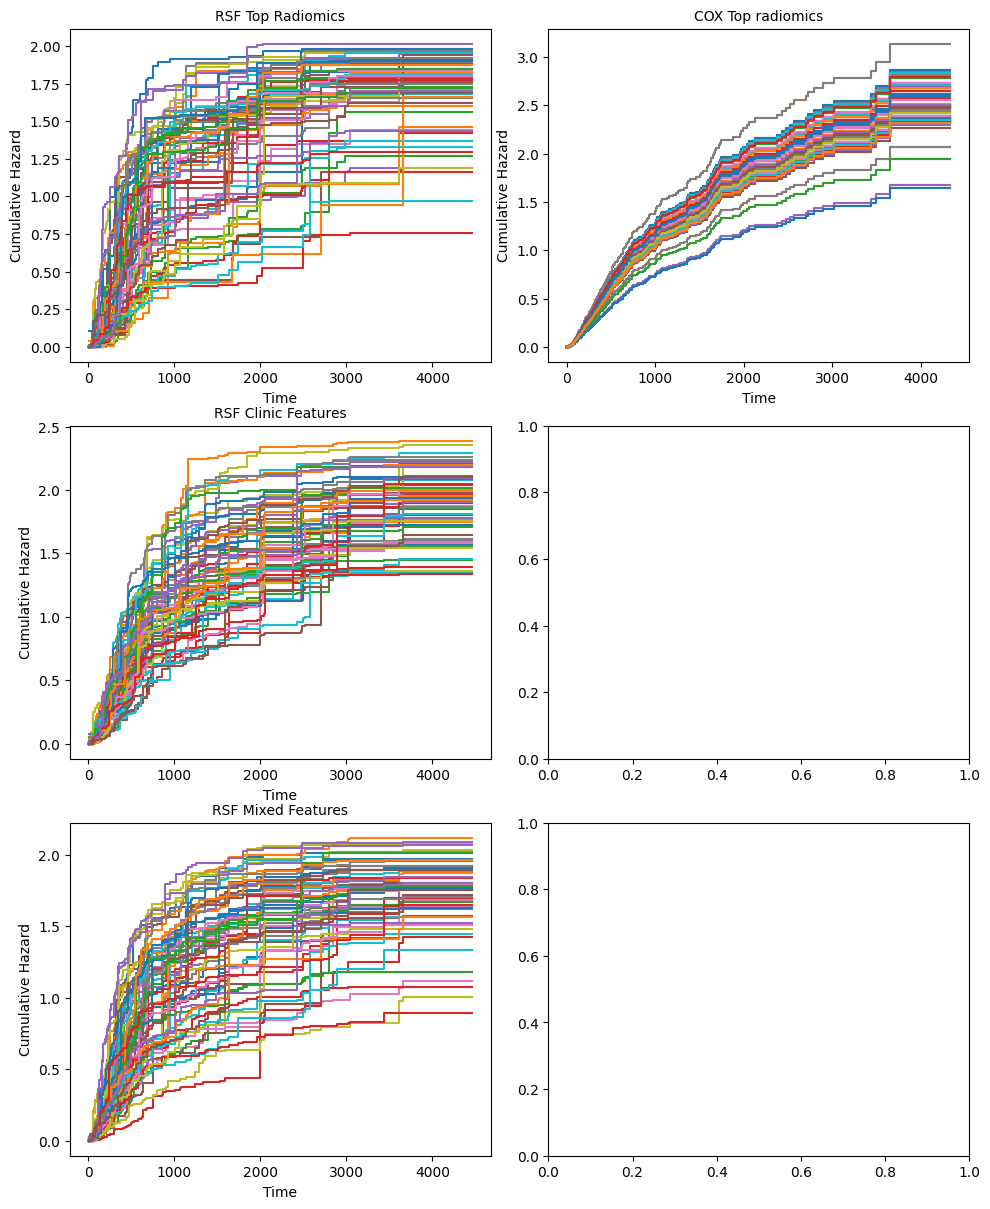

In [ ]:
ax = axes_flat[1]

chf_functions = best_classifier.predict_cumulative_hazard_function(X_test)
for fn in chf_functions:
    ax.step(fn.x, fn(fn.x), where="post")

ax.set_title("COX Top radiomics", fontsize=10)
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative Hazard")
fig

### COX Proportional Hazards Model - Clinical features only

In [ ]:
features_clinic = df_clinic.columns[1:8]


In [ ]:
df_clinic2 = df_clinic.dropna()
X = df_clinic2[features_clinic].reset_index(drop=True)
event = df_clinic2['deadstatus.event'].values.astype(bool)
time = df_clinic2['Survival.time'].values

y = np.array([(e, t) for e, t in zip(event, time)], 
             dtype=[('event', '?'), ('time', '<f8')])

categorical_features = ["Overall.Stage", "Histology", "gender"]
numerical_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, drop='first'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ],
    remainder='passthrough'
)

X_encoded = preprocessor.fit_transform(X)


outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_index, test_index = next(outer_cv.split(X_encoded, event))
X_train_set, X_test_set = X_encoded[train_index], X_encoded[test_index]
y_train_set, y_test_set = y[train_index], y[test_index]
event_train_set = event[train_index] 


inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

c_indices = []
best_classifier = None
best_c_index = -1
best_fold = -1

for fold, (train_idx, test_idx) in enumerate(inner_cv.split(X_train_set, event_train_set)):
    X_train, X_test = X_train_set[train_idx], X_train_set[test_idx]
    y_train, y_test = y_train_set[train_idx], y_train_set[test_idx]
    
    classifier = CoxPHSurvivalAnalysis(alpha=1e-4) 
    classifier.fit(X_train, y_train)
    

    risk_scores = classifier.predict(X_test)
    
    c_index = concordance_index_censored(
        y_test['event'],
        y_test['time'],
        risk_scores
    )[0]
    c_indices.append(c_index)
    
    if c_index > best_c_index:
        best_c_index = c_index
        best_classifier = classifier
        best_fold = fold

print(f"Concordance Index Scores: {[f'{c:.4f}' for c in c_indices]}")
print(f"Mean Concordance Index: {np.mean(c_indices):.4f} (+/- {np.std(c_indices):.4f})")
print(f"\nBest Classifier - Fold {best_fold}: Concordance Index = {best_c_index:.4f}")
print("Cross-validation complete!")
joblib.dump(best_classifier, 'models/cox_clinics.pkl')

Concordance Index Scores: ['0.5546', '0.5171', '0.5275', '0.5666', '0.4542']
Mean Concordance Index: 0.5240 (+/- 0.0392)

Best Classifier - Fold 3: Concordance Index = 0.5666
Cross-validation complete!


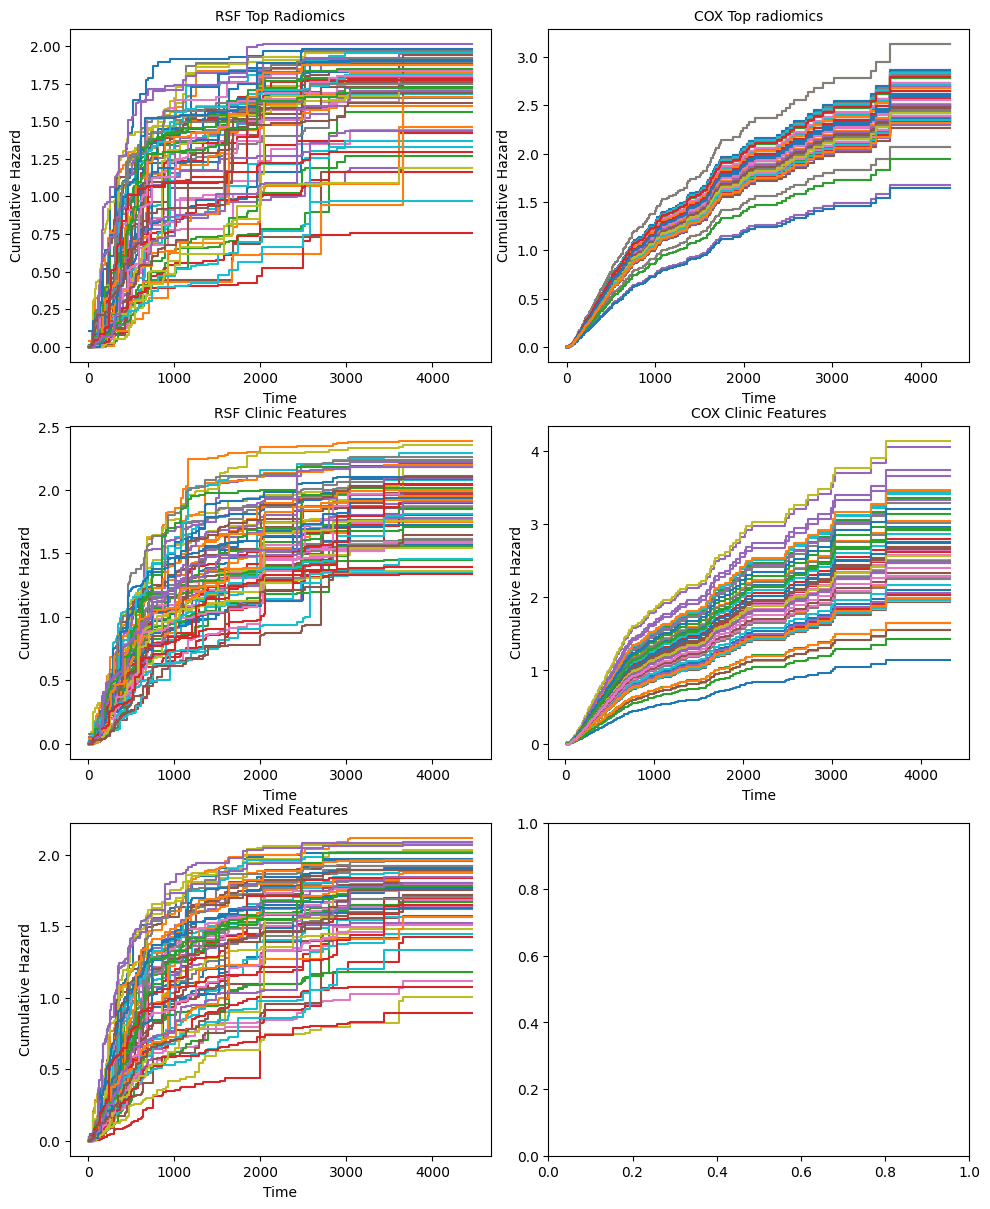

In [ ]:
ax = axes_flat[3]

chf_functions = best_classifier.predict_cumulative_hazard_function(X_test)
for fn in chf_functions:
    ax.step(fn.x, fn(fn.x), where="post")

ax.set_title("COX Clinic Features", fontsize=10)
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative Hazard")
fig

### COX Proportional Hazards Model - MIXED

In [ ]:
features_clinic = df_clinic.columns[1:8]
features_radiomics = ["wavelet-LLH_ngtdm_Coarseness","original_gldm_DependenceNonUniformity", "wavelet-HHL_ngtdm_Coarseness", "wavelet-HHL_glrlm_RunLengthNonUniformity"]

In [ ]:

df_clinic2 = df_clinic.dropna()
df_radiomics2 = df_radiomics.dropna() 
X_clinic = df_clinic2[features_clinic].reset_index(drop=True)
X_radiomics = df_radiomics2[features_radiomics].reset_index(drop=True)

X = pd.concat([X_clinic, X_radiomics], axis=1)
X.dropna(inplace=True)  

event = df_clinic2['deadstatus.event'].values.astype(bool)
time = df_clinic2['Survival.time'].values

y = np.array([(e, t) for e, t in zip(event, time)], 
             dtype=[('event', '?'), ('time', '<f8')])

categorical_features = ['Overall.Stage', 'Histology', 'gender']
numerical_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, drop='first'), categorical_features), 
        ('num', StandardScaler(), numerical_features)
    ],
    remainder='passthrough'
)

X_encoded = preprocessor.fit_transform(X)

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_index, test_index = next(outer_cv.split(X_encoded, event))
X_train_set, X_test_set = X_encoded[train_index], X_encoded[test_index]
y_train_set, y_test_set = y[train_index], y[test_index]
event_train_set = event[train_index] 


inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

c_indices = []
best_classifier = None
best_c_index = -1
best_fold = -1

for fold, (train_idx, test_idx) in enumerate(inner_cv.split(X_train_set, event_train_set)):
    X_train, X_test = X_train_set[train_idx], X_train_set[test_idx]
    y_train, y_test = y_train_set[train_idx], y_train_set[test_idx]
    
    classifier = CoxPHSurvivalAnalysis(alpha=1e-4) 
    classifier.fit(X_train, y_train)

    risk_scores = classifier.predict(X_test)
    
    c_index = concordance_index_censored(
        y_test['event'],
        y_test['time'],
        risk_scores
    )[0]
    c_indices.append(c_index)
    
    if c_index > best_c_index:
        best_c_index = c_index
        best_classifier = classifier
        best_fold = fold

print(f"Concordance Index Scores: {[f'{c:.4f}' for c in c_indices]}")
print(f"Mean Concordance Index: {np.mean(c_indices):.4f} (+/- {np.std(c_indices):.4f})")
print(f"\nBest Classifier - Fold {best_fold}: Concordance Index = {best_c_index:.4f}")
print("Cross-validation complete!")
joblib.dump(best_classifier, 'models/cox_mixed.pkl')


Concordance Index Scores: ['0.5603', '0.5034', '0.5300', '0.5544', '0.4637']
Mean Concordance Index: 0.5224 (+/- 0.0356)

Best Classifier - Fold 0: Concordance Index = 0.5603
Cross-validation complete!


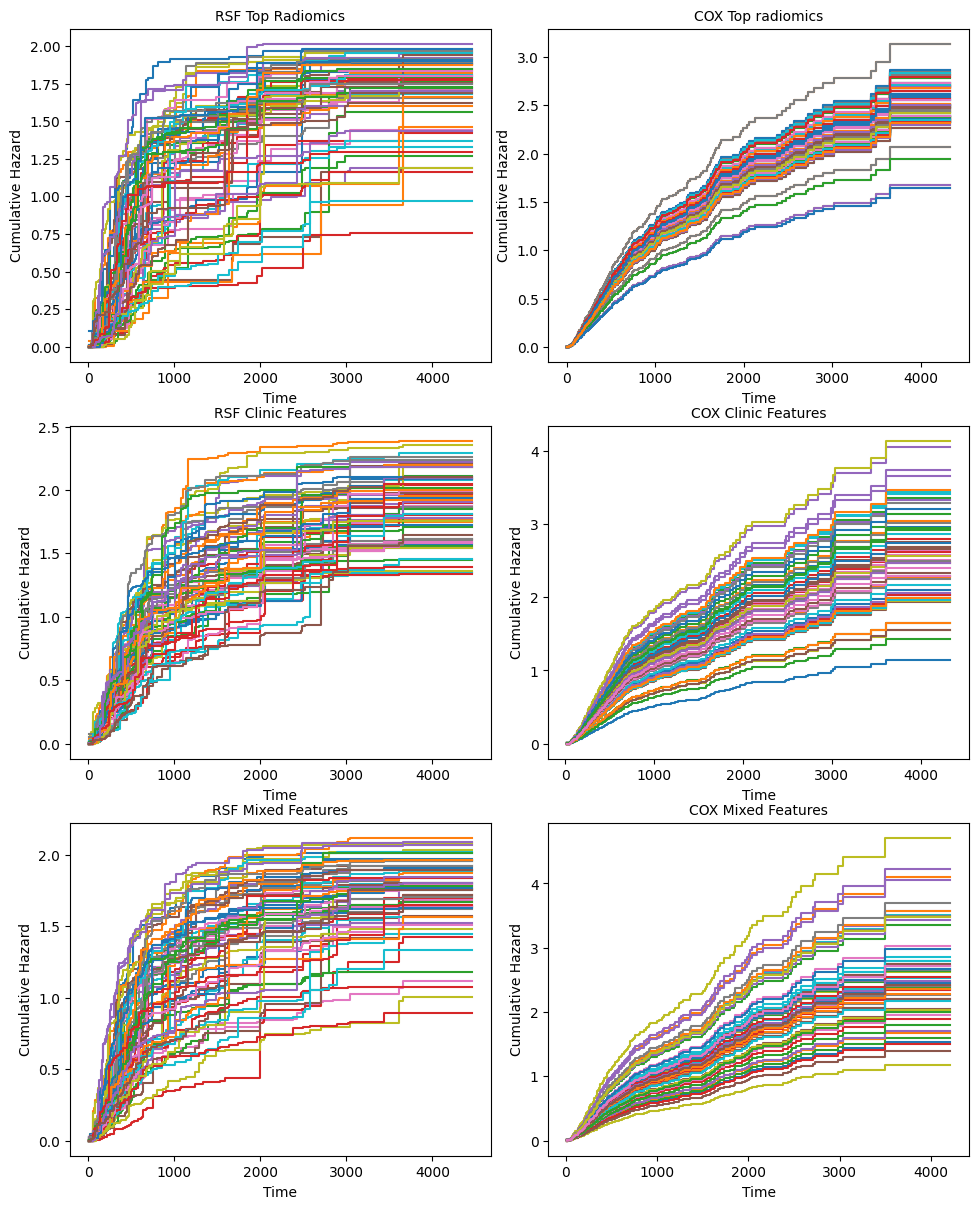

In [ ]:
ax = axes_flat[5]

chf_functions = best_classifier.predict_cumulative_hazard_function(X_test)
for fn in chf_functions:
    ax.step(fn.x, fn(fn.x), where="post")

ax.set_title("COX Mixed Features", fontsize=10)
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative Hazard")
fig